In [ ]:
# 10 frames of data

In [2]:
import os
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.dataframe as dd
from SciFiReaders import NSIDReader

# Support kernels started from either the repo root or notebooks folder.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
from event_pipeline import build_events, sort_to_parquet

%matplotlib ipympl


In [5]:
path = '/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/'

# experiment_name = 'MoS2_Moire_2k'
experiment_name = 'TestSeq1_1k'


files = os.listdir(path)
files = [f for f in files if f.endswith('.h5')]
files = [f for f in files if experiment_name in f]

files.sort()
files



['TestSeq1_1k_ep0_ch1_proc0.h5',
 'TestSeq1_1k_ep0_ch1_proc1.h5',
 'TestSeq1_1k_ep0_ch1_proc10.h5',
 'TestSeq1_1k_ep0_ch1_proc11.h5',
 'TestSeq1_1k_ep0_ch1_proc12.h5',
 'TestSeq1_1k_ep0_ch1_proc13.h5',
 'TestSeq1_1k_ep0_ch1_proc14.h5',
 'TestSeq1_1k_ep0_ch1_proc15.h5',
 'TestSeq1_1k_ep0_ch1_proc2.h5',
 'TestSeq1_1k_ep0_ch1_proc3.h5',
 'TestSeq1_1k_ep0_ch1_proc4.h5',
 'TestSeq1_1k_ep0_ch1_proc5.h5',
 'TestSeq1_1k_ep0_ch1_proc6.h5',
 'TestSeq1_1k_ep0_ch1_proc7.h5',
 'TestSeq1_1k_ep0_ch1_proc8.h5',
 'TestSeq1_1k_ep0_ch1_proc9.h5',
 'TestSeq1_1k_ep1_ch1_proc0.h5',
 'TestSeq1_1k_ep1_ch1_proc1.h5',
 'TestSeq1_1k_ep1_ch1_proc10.h5',
 'TestSeq1_1k_ep1_ch1_proc11.h5',
 'TestSeq1_1k_ep1_ch1_proc12.h5',
 'TestSeq1_1k_ep1_ch1_proc13.h5',
 'TestSeq1_1k_ep1_ch1_proc14.h5',
 'TestSeq1_1k_ep1_ch1_proc15.h5',
 'TestSeq1_1k_ep1_ch1_proc2.h5',
 'TestSeq1_1k_ep1_ch1_proc3.h5',
 'TestSeq1_1k_ep1_ch1_proc4.h5',
 'TestSeq1_1k_ep1_ch1_proc5.h5',
 'TestSeq1_1k_ep1_ch1_proc6.h5',
 'TestSeq1_1k_ep1_ch1_proc7.h5'

In [6]:
# Open the same file directly with h5py and inspect its contents.
# If this file is locked by another reader, close that reader first,
# or choose another file (for example, files[1]).
h5_path = os.path.join(path, files[0])

with h5py.File(h5_path, "r") as h5:
    print("File:", h5_path)
    print("File attributes:", dict(h5.attrs))

    def show_dataset(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}: shape={obj.shape}, dtype={obj.dtype}")

    h5.visititems(show_dataset)  # Also finds datasets inside nested groups.


File: /Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/TestSeq1_1k_ep0_ch1_proc0.h5
File attributes: {}
control: shape=(21507,), dtype=uint64
ftoa_fall: shape=(297983460,), dtype=uint8
ftoa_rise: shape=(297983460,), dtype=uint8
lvds_timestamp: shape=(0,), dtype=uint64
pileup: shape=(297983460,), dtype=uint8
sw_lvds_fe_timestamp: shape=(0,), dtype=uint64
sw_lvds_re_timestamp: shape=(0,), dtype=uint64
sw_pulse_timestamp: shape=(0,), dtype=uint64
sw_ttl_fe_timestamp: shape=(0,), dtype=uint64
sw_ttl_re_timestamp: shape=(21504,), dtype=uint64
toa: shape=(297983460,), dtype=uint64
tot: shape=(297983460,), dtype=uint16
ttl_timestamp: shape=(0,), dtype=uint64
uftoa_start: shape=(297983460,), dtype=uint8
uftoa_stop: shape=(297983460,), dtype=uint8
x: shape=(297983460,), dtype=uint16
y: shape=(297983460,), dtype=uint16


In [7]:
# Read just the first 10 events: slicing avoids loading the whole file.
# These dataset names are present in your H5 files.
with h5py.File(h5_path, "r") as h5:
    x_sample = h5["x"][:10]
    y_sample = h5["y"][:10]
    toa_sample = h5["toa"][:10]
    tot_sample = h5["tot"][:10]
    print("toa attributes:", dict(h5["toa"].attrs))

# The slices are NumPy arrays, so they remain usable after the file closes.
print("x:", x_sample)
print("y:", y_sample)
print("toa:", toa_sample)
print("tot:", tot_sample)


toa attributes: {}
x: [227 227 221 261 174 285 201 306 196 221]
y: [ 88  89 165 149 176 180 185 186 130 166]
toa: [45580312 45580312 45580302 45580309 45580301 45580308 45580304 45580304
 45580296 45580301]
tot: [ 2 36  3 10 14  6  3  6  4 20]


### Lazy event table and memory-managed time sort
Each partition reads at most 100,000 events. Column dtypes are preserved; `file_id` and `event_id` identify the original event. `fields=None` includes every root-level 1D column aligned with `toa`; empty control/timestamp streams are excluded and remain in the source H5 files.

Only shapes and dtypes are read during construction. Close any existing NSIDReader first (`reader.close()`) if it locks an input. Do not use `events.compute()` or `events.persist()` for the full collection.

Before combining epochs, confirm that their `toa` values share the same clock origin and units. Sorting raw timestamps does not correct clock resets or rollover.


In [8]:

events, manifest = build_events(path, batch_rows=100_000, fields=None)
print(events.dtypes)
print("Partitions:", events.npartitions)
manifest  # Maps file_id to source filename and event count.


ftoa_fall       uint8
ftoa_rise       uint8
pileup          uint8
toa            uint64
tot            uint16
uftoa_start     uint8
uftoa_stop      uint8
x              uint16
y              uint16
file_id        uint32
event_id       uint64
dtype: object
Partitions: 237007


,file_id,filename,events
0,0,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/MoS2_...,429765739
1,1,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/MoS2_...,429767792
2,2,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/MoS2_...,429812415
3,3,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/MoS2_...,429817437
4,4,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/MoS2_...,429766263
...,...,...,...
59,59,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/TestS...,319311992
60,60,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/TestS...,319216284
61,61,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/TestS...,319232331
62,62,/Volumes/Extreme SSD/Timepix/MoS2_Kai_5b/TestS...,319222514


In [9]:
# Read only the first partition's first 10 rows.
events.head(10, npartitions=1)


KeyboardInterrupt: 

The next cell executes the full sort and writes a Parquet directory. It uses one worker process, one active task thread, a 2 GiB worker budget, and disk spilling. Leave RAM for the notebook and OS, and substantial free disk space for shuffle files and output. These are safeguards, not a strict memory guarantee: skewed/repeated timestamps can create oversized partitions. If the worker repeatedly restarts, stop and use an external merge sort or smaller, explicit time windows.

Equal timestamps have no guaranteed tie order. All event columns stay together. Reopen the output lazily for subsequent experiments.


In [8]:
output_directory = Path("../outputs/events_sorted_by_toa")
spill_directory = Path("../outputs/.dask-spill")

sorted_events = sort_to_parquet(
    events, manifest, output_directory, spill_directory,
    worker_memory="2GiB",
    output_partitions=events.npartitions,
)


2026-10-05 09:23:34,095 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ec4b2690c9064ae236f85ec323bd9b35 initialized by task ('shuffle-transfer-ec4b2690c9064ae236f85ec323bd9b35', 116) executed on worker tcp://127.0.0.1:53119
2026-10-05 09:24:18,026 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ec4b2690c9064ae236f85ec323bd9b35 deactivated due to stimulus 'task-finished-1791206658.025439'


In [9]:
# In a later session, no H5 handles are needed.
sorted_events = dd.read_parquet(output_directory)
sorted_events.head(10, npartitions=1)
# Select a time window lazily: sorted_events.loc[start_toa:stop_toa]


,ftoa_fall,ftoa_rise,pileup,tot,uftoa_start,uftoa_stop,x,y,file_id,event_id
toa,,,,,,,,,,
93953928,3,5,0,11,0,0,200,255,5,93
93953928,1,5,0,11,0,0,200,254,5,74
93953929,7,0,0,11,0,3,120,300,21,56
93953930,4,1,0,2,0,6,245,177,5,17
93953930,12,15,0,8,3,5,231,249,5,97
93953930,6,6,0,23,0,7,246,177,5,40
93953930,6,12,0,13,0,5,242,207,5,42
93953930,14,12,0,8,0,4,242,208,5,50
93953930,0,7,0,25,0,3,173,228,5,38


In [10]:
ymin = sorted_events.y.min().compute()
ymax = sorted_events.y.max().compute()
xmin = sorted_events.x.min().compute()
xmax = sorted_events.x.max().compute()

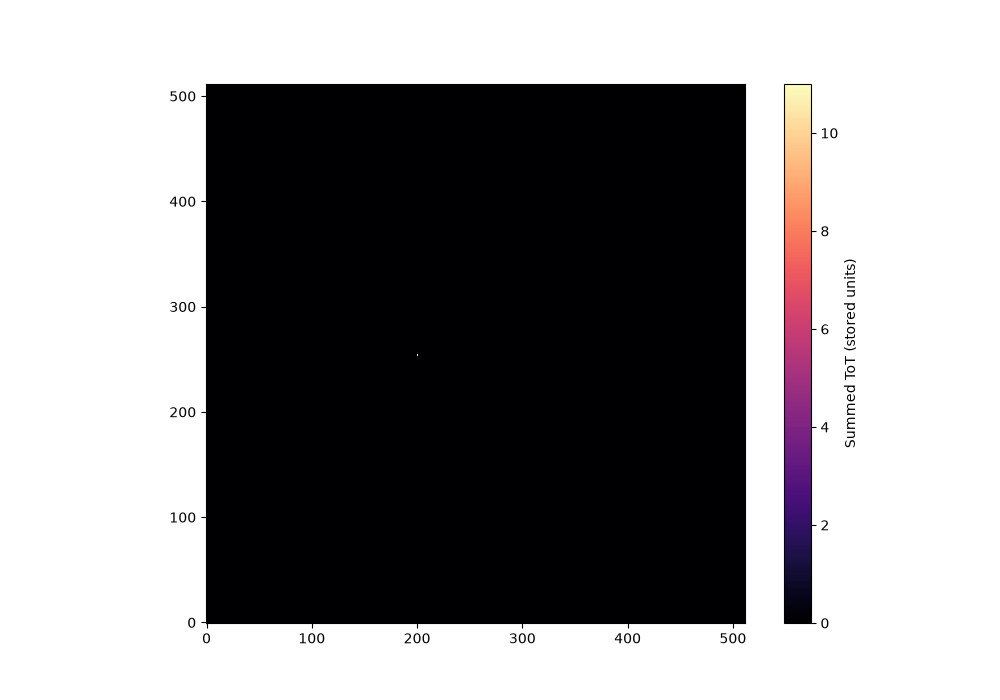

In [11]:
# Sum ToT at detector pixels for the first 100 events in toa order.
n_events = 2
# Assumes zero-based pixel coordinates. Use the known detector width here
# if available; max observed coordinate + 1 gives an inferred square size.
detector_size = int(max(xmax, ymax)) + 1

# Read successive partitions only until enough events have been collected.
# A partition is read into memory, but the full event table is never loaded.
parts = []
remaining = n_events
for partition_id in range(sorted_events.npartitions):
    part = sorted_events[["x", "y", "tot"]].get_partition(partition_id).head(
        remaining, npartitions=1
    )
    if len(part):
        parts.append(part)
        remaining -= len(part)
    if remaining == 0:
        break

if not parts:
    raise ValueError("No events available to plot")
plot_events = pd.concat(parts)
x_pixels = plot_events["x"].to_numpy(dtype=np.int64)
y_pixels = plot_events["y"].to_numpy(dtype=np.int64)
weights = plot_events["tot"].to_numpy(dtype=np.float64)
if ((x_pixels < 0).any() or (y_pixels < 0).any()
        or (x_pixels >= detector_size).any() or (y_pixels >= detector_size).any()):
    raise ValueError("Event coordinates fall outside the detector")

# Image indexing is [row, column] = [y, x]. add.at sums repeated pixels.
detector_image = np.zeros((detector_size, detector_size), dtype=np.float64)
np.add.at(detector_image, (y_pixels, x_pixels), weights)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(detector_image, origin="lower", interpolation="nearest",
               cmap="magma", aspect="equal")
fig.colorbar(im, ax=ax, label="Summed ToT (stored units)")
plt.show()
